## EGWUOGU IBUKUN ##
## Machine Learning – Resource Replication on Feature Selection ##

### RESOURCE VERSION 1 ###

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine

%matplotlib inline

In [53]:
plt.rcParams["figure.figsize"] = (12, 9)

#### Read the data ####

In [56]:
wine_data = load_wine()

wine_df = pd.DataFrame(
    data = wine_data.data,
    columns = wine_data.feature_names
)

wine_df['target'] = wine_data.target

wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


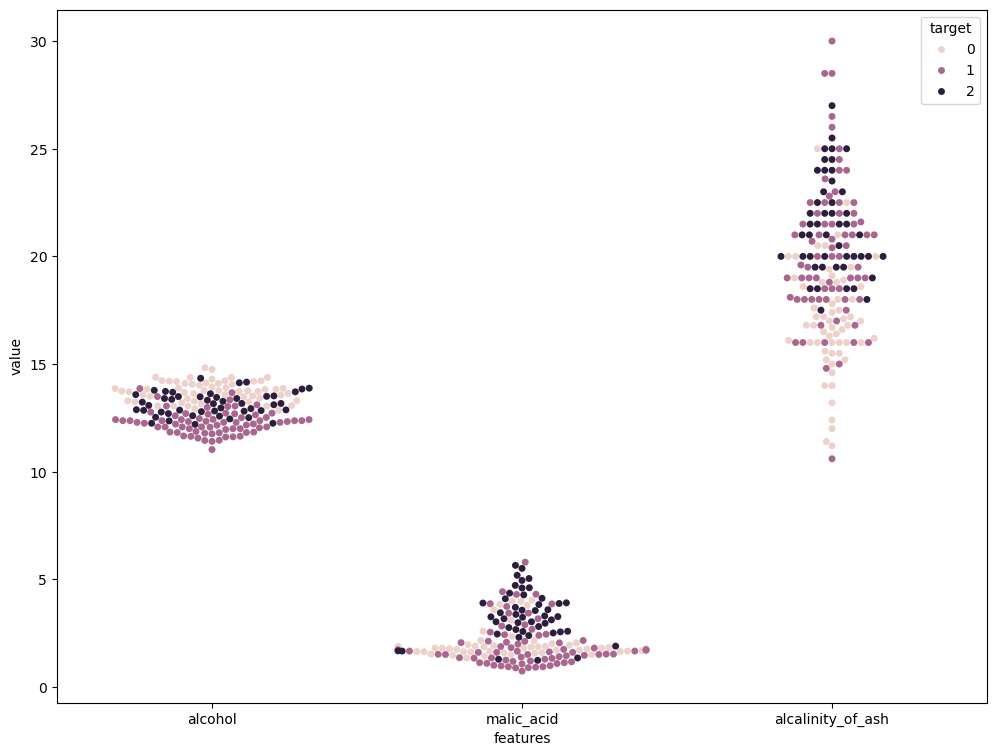

In [68]:
from seaborn import swarmplot

data_to_plot = pd.melt(wine_df[['alcohol', 'malic_acid', 'alcalinity_of_ash', 'target']],
                       id_vars = 'target',
                       var_name = 'features',
                       value_name = 'value')

swarmplot(data = data_to_plot, x = 'features', y = 'value', hue = 'target');
plt.show()

In [60]:
wine_df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

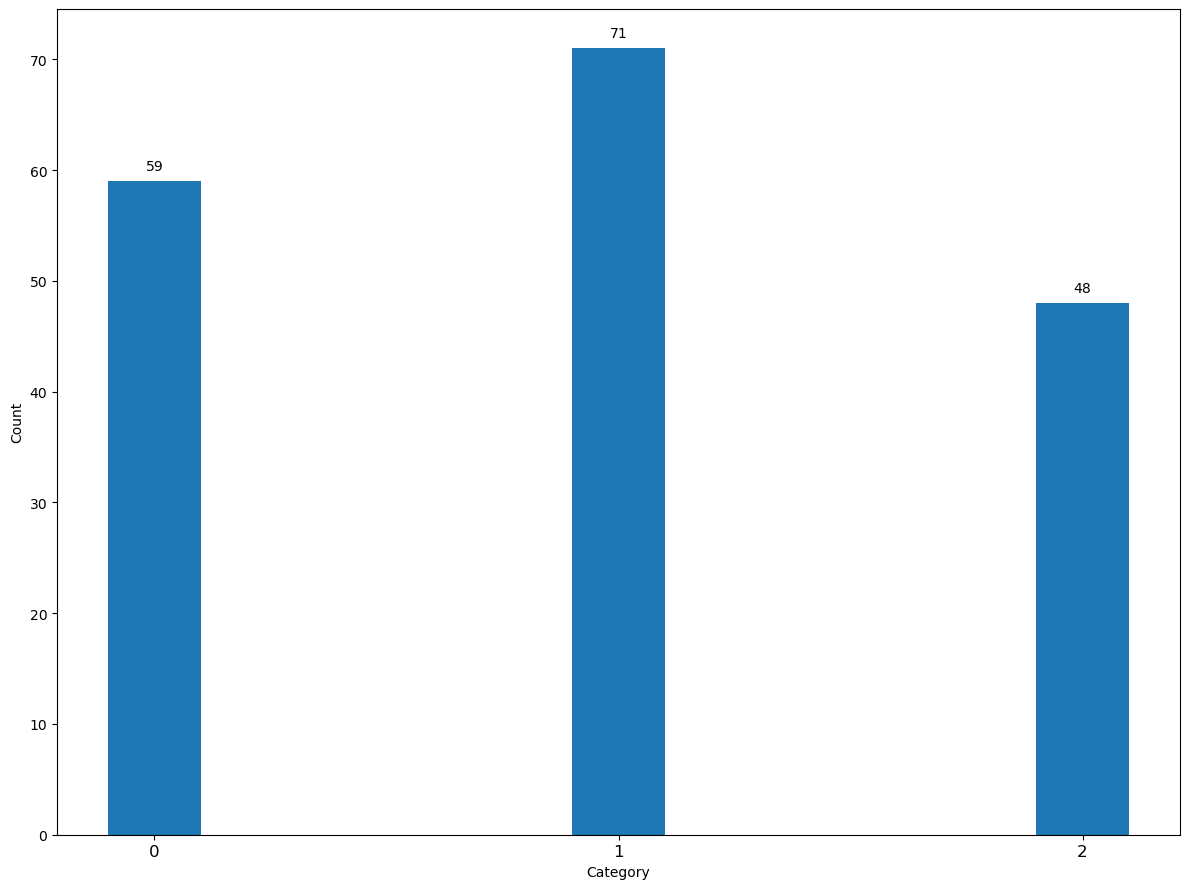

In [80]:
fig, ax = plt.subplots()

x = [0, 1, 2]
y = [59, 71, 48]

ax.bar(x, y, width = 0.2)
ax.set_xlabel('Category')
ax.set_ylabel('Count')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels([0, 1, 2], fontsize = 12)

for index, value in enumerate (y):
    plt.text(x = int(index), y = value + 1, s = str(value), ha = 'center')

plt.tight_layout()
plt.show()

#### Train/test Split ####

In [83]:
from sklearn.model_selection import train_test_split

x = wine_df.drop(['target'], axis = 1)
y = wine_df['target']

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size = 0.3,
                                                    shuffle = True,
                                                    stratify = y,
                                                    random_state = 42)

In [85]:
print(x_train.shape)
print(x_test.shape)

(124, 13)
(54, 13)


#### Baseline model: Gradient Boosting Classifier with all features ####

In [90]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score

#Initialize classifier
gbc = GradientBoostingClassifier(max_depth = 5, random_state = 42)

#Train classifier using all feature
gbc.fit(x_train, y_train)

#Make predictions
preds = gbc.predict(x_test)

#Evaluate the model using the F1 score
f1_score_all = round(f1_score(y_test, preds, average = 'weighted'), 3)

print(f1_score_all)

0.908


### Feature Selection Techniques ###

#### Variance Method ####

In [94]:
x_train_v1, x_test_v1, y_train_v1, y_test_v1 = x_train.copy(), x_test.copy(), y_train.copy(), y_test.copy()

In [96]:
#Calculate the variance of each feature

x_train_v1.var(axis = 0)

alcohol                             0.658341
malic_acid                          1.123507
ash                                 0.072433
alcalinity_of_ash                  11.471279
magnesium                         232.071532
total_phenols                       0.393226
flavanoids                          0.912299
nonflavanoid_phenols                0.013873
proanthocyanins                     0.335108
color_intensity                     5.669722
hue                                 0.052891
od280/od315_of_diluted_wines        0.470021
proline                         94906.710923
dtype: float64

In [98]:
#We need to scale our data before doing variance comparism
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_x_train_v1 = scaler.fit_transform(x_train_v1)

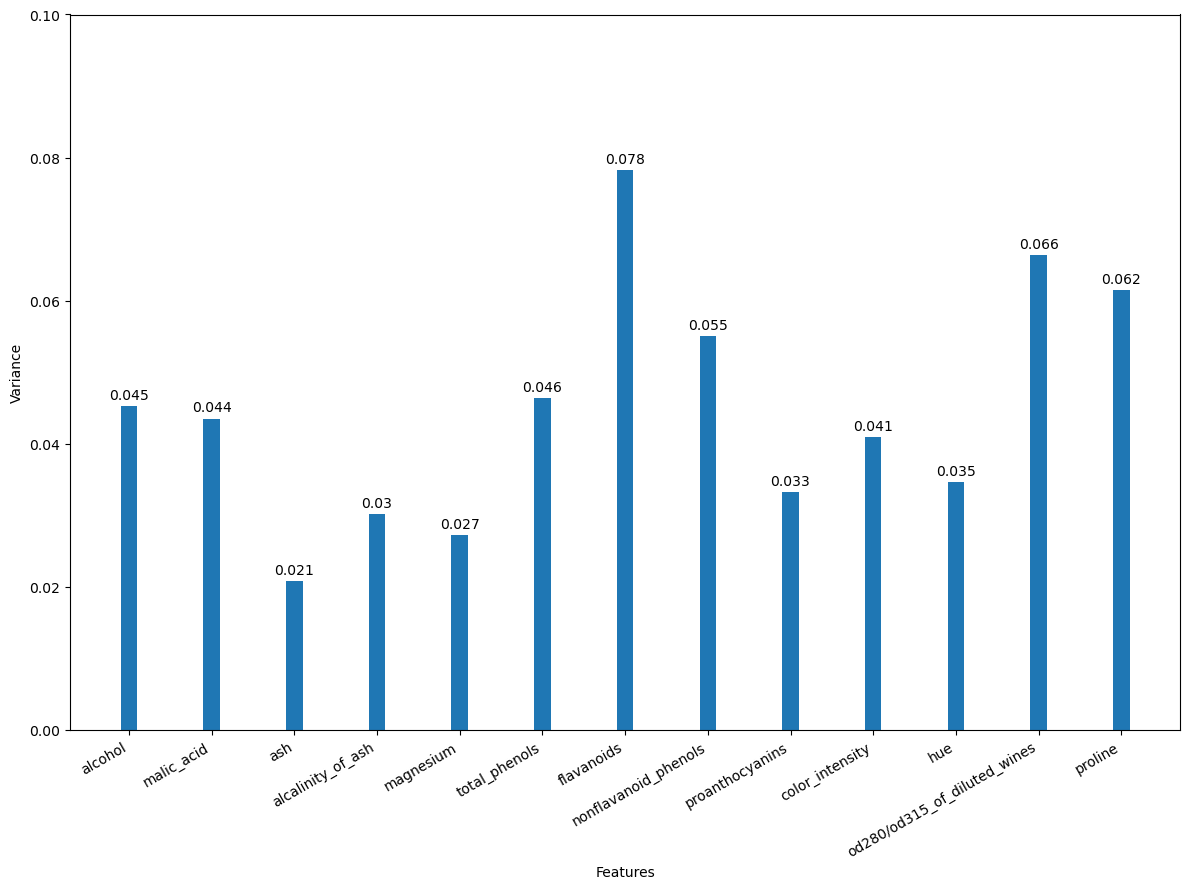

In [100]:
fig, ax = plt.subplots()

x = x.columns
y = scaled_x_train_v1.var(axis = 0)

ax.bar(x, y, width = 0.2)
ax.set_xlabel('Features')
ax.set_ylabel('Variance')
ax.set_ylim(0, 0.1)

for index, value in enumerate (y):
    plt.text(x = int(index), y = value + 0.001, s = str(round(value, 3)), ha = 'center')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [108]:
#Setting threshold to 0.03
sel_x_train_v1 = x_train_v1.drop(['ash', 'magnesium'], axis = 1)
sel_x_test_v1 = x_test_v1.drop(['ash', 'magnesium'], axis = 1)

gbc.fit(sel_x_train_v1, y_train_v1)

var_preds = gbc.predict(sel_x_test_v1)

f1_score_var = round(f1_score(y_test_v1, var_preds, average = 'weighted'), 3)

print(f1_score_var)

0.963


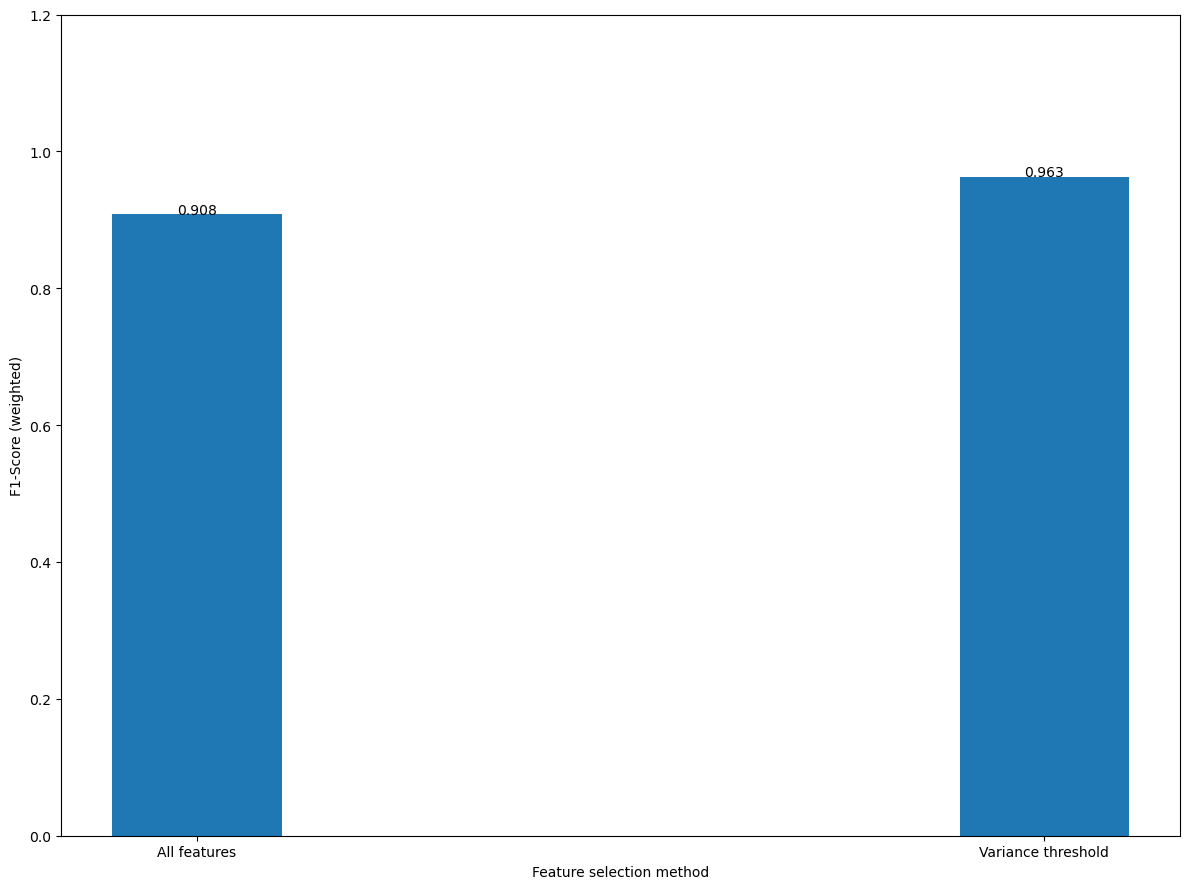

In [110]:
fig, ax = plt.subplots()

x = ['All features', 'Variance threshold']
y = [f1_score_all, f1_score_var]

ax.bar(x, y, width = 0.2)
ax.set_xlabel('Feature selection method')
ax.set_ylabel('F1-Score (weighted)')
ax.set_ylim(0, 1.2)

for index, value in enumerate (y):
    plt.text(x = int(index), y = value + 0.001, s = str(round(value, 3)), ha = 'center')

plt.tight_layout()
plt.show()

#### K-best Features (Filter Method) ###

In [113]:
x_train_v2, x_test_v2, y_train_v2, y_test_v2 = x_train.copy(), x_test.copy(), y_train.copy(), y_test.copy()

In [115]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

f1_score_list = []

for k in range(1, 14):
    selector = SelectKBest(mutual_info_classif, k = k)
    selector.fit(x_train_v2, y_train_v2)

    sel_x_train_v2 = selector.transform(x_train_v2)
    sel_x_test_v2 = selector.transform(x_test_v2)

    gbc.fit(sel_x_train_v2, y_train_v2)
    kbest_preds = gbc.predict(sel_x_test_v2)

    f1_score_kbest = round(f1_score(y_test_v2, kbest_preds, average = 'weighted'), 3)

    f1_score_list.append(f1_score_kbest)

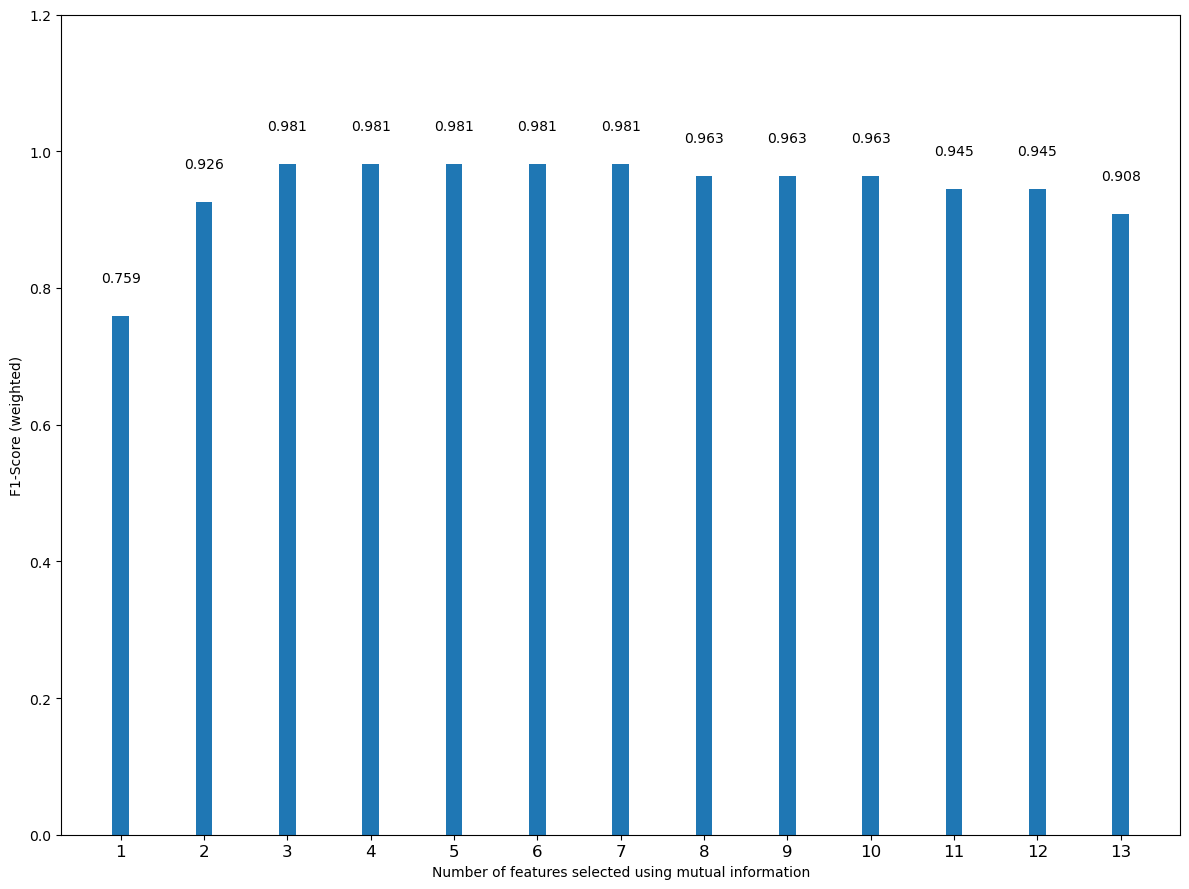

In [123]:
fig, ax = plt.subplots()

x = np.arange(1, 14)
y = f1_score_list

ax.bar(x, y, width = 0.2)
ax.set_xlabel('Number of features selected using mutual information')
ax.set_ylabel('F1-Score (weighted)')
ax.set_ylim(0, 1.2)
ax.set_xticks(np.arange(1, 14))
ax.set_xticklabels(np.arange(1, 14), fontsize = 12)

for i, v in enumerate (y):
    plt.text(x = i+1, y = v + 0.05, s = str(v), ha = 'center')

plt.tight_layout()
plt.show()

In [129]:
#Finding out which features have been selected
selector = SelectKBest(mutual_info_classif, k = 3)
selector.fit(x_train_v2, y_train_v2)

selected_feature_mask = selector.get_support()

selected_features = x_train_v2.columns[selected_feature_mask]

selected_features

Index(['flavanoids', 'color_intensity', 'proline'], dtype='object')

#### Recursive Feature Elimination Method ####

In [132]:
x_train_v3, x_test_v3, y_train_v3, y_test_v3 = x_train.copy(), x_test.copy(), y_train.copy(), y_test.copy()

In [134]:
from sklearn.feature_selection import RFE

rfe_f1_score_list = []

for k in range(1, 14):
    RFE_selector = RFE(estimator = gbc, n_features_to_select = k, step = 1)
    RFE_selector.fit(x_train_v3, y_train_v3)

    sel_x_train_v3 = RFE_selector.transform(x_train_v3)
    sel_x_test_v3 = RFE_selector.transform(x_test_v3)

    gbc.fit(sel_x_train_v3, y_train_v3)
    RFE_preds = gbc.predict(sel_x_test_v3)

    f1_score_rfe = round(f1_score(y_test_v3, RFE_preds, average = 'weighted'), 3)

    rfe_f1_score_list.append(f1_score_rfe)

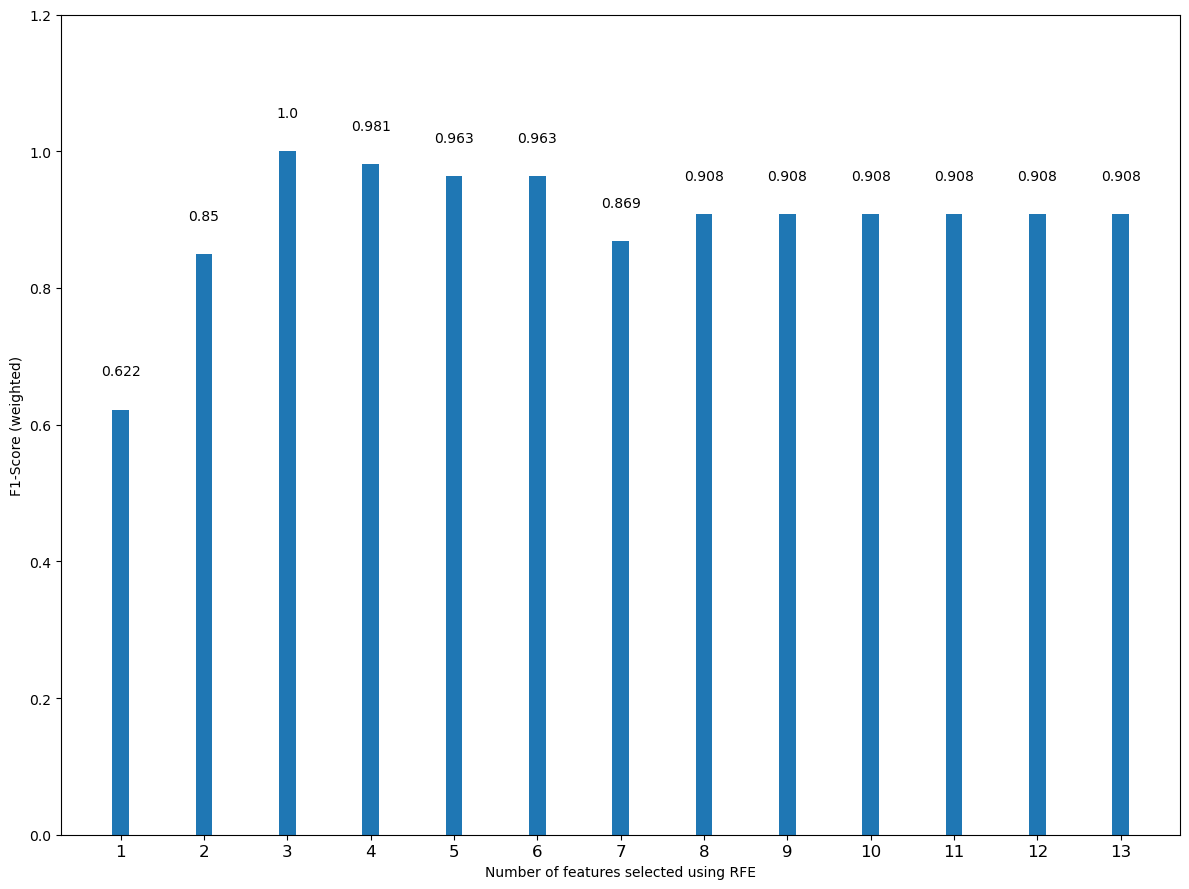

In [136]:
fig, ax = plt.subplots()

x = np.arange(1, 14)
y = rfe_f1_score_list

ax.bar(x, y, width = 0.2)
ax.set_xlabel('Number of features selected using RFE')
ax.set_ylabel('F1-Score (weighted)')
ax.set_ylim(0, 1.2)
ax.set_xticks(np.arange(1, 14))
ax.set_xticklabels(np.arange(1, 14), fontsize = 12)

for i, v in enumerate (y):
    plt.text(x = i+1, y = v + 0.05, s = str(v), ha = 'center')

plt.tight_layout()
plt.show()

In [138]:
#Checking with features were selected by the RFE algorithm
RFE_selector = RFE(estimator = gbc, n_features_to_select = 3, step = 10)
RFE_selector.fit(x_train_v3, y_train_v3)

selected_features_mask = RFE_selector.get_support()

selected_features = x_train_v3.columns[selected_features_mask]
selected_features

Index(['color_intensity', 'od280/od315_of_diluted_wines', 'proline'], dtype='object')

#### Boruta Method ####

In [141]:
x_train_v4, x_test_v4, y_train_v4, y_test_v4 = x_train.copy(), x_test.copy(), y_train.copy(), y_test.copy()

In [ ]:
import sys
!{sys.executable} -m pip install Boruta

In [156]:
from boruta import BorutaPy

boruta_selector = BorutaPy(gbc, random_state = 42)

boruta_selector.fit(x_train_v4.values, y_train_v4.values.ravel())

sel_x_train_v4 = boruta_selector.transform(x_train_v4.values)
sel_x_test_v4 = boruta_selector.transform(x_test_v4.values)

gbc.fit(sel_x_train_v4, y_train_v4)

boruta_preds = gbc.predict(sel_x_test_v4)

boruta_f1_score = round(f1_score(y_test_v4, boruta_preds, average='weighted'), 3)

In [158]:
#Checking the elected features
selected_features_mask = boruta_selector.support_

selected_features = x_train_v4.columns[selected_features_mask]
selected_features

Index(['malic_acid', 'ash', 'magnesium', 'flavanoids', 'proanthocyanins',
       'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

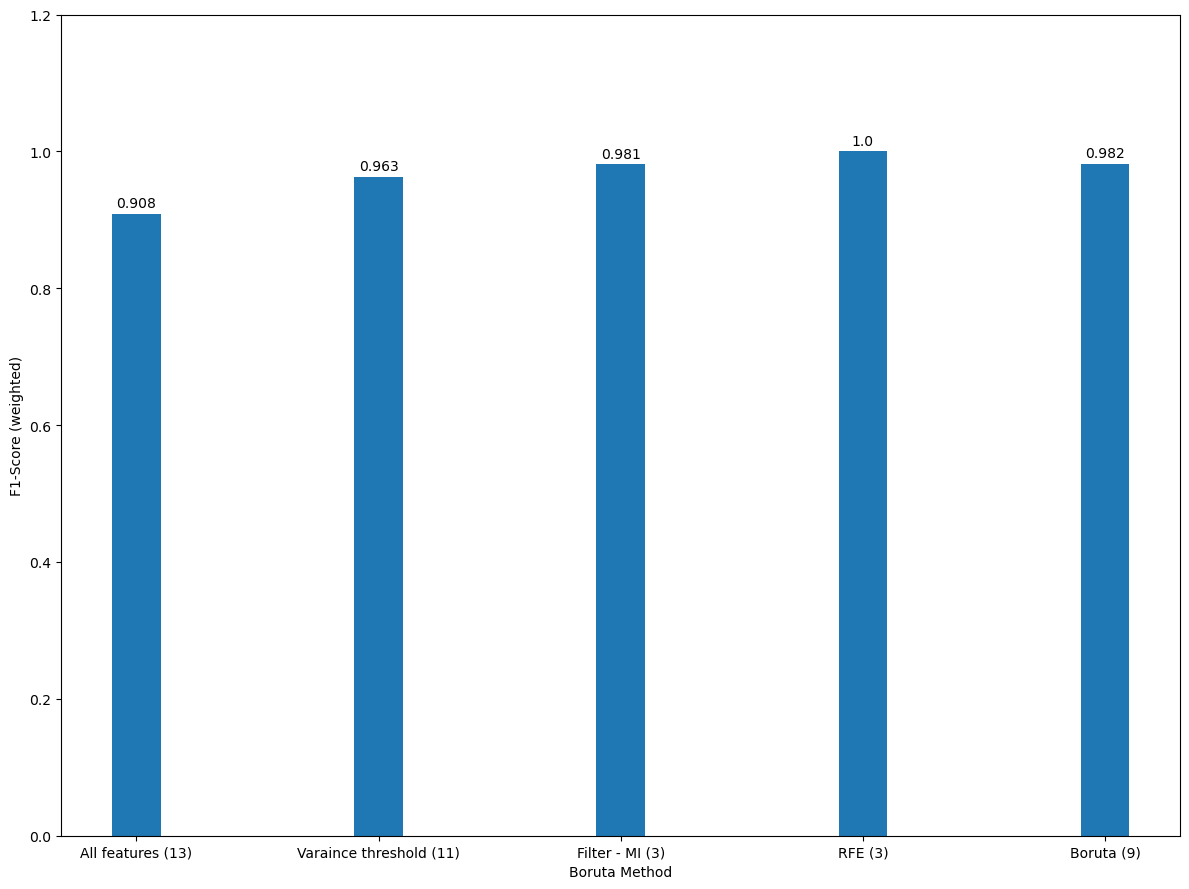

In [162]:
fig, ax = plt.subplots()

x = ['All features (13)', 'Varaince threshold (11)', 'Filter - MI (3)', 'RFE (3)', 'Boruta (9)']
y = [f1_score_all, f1_score_var, 0.981, 1.0, boruta_f1_score]

ax.bar(x, y, width = 0.2)
ax.set_xlabel('Boruta Method')
ax.set_ylabel('F1-Score (weighted)')
ax.set_ylim(0, 1.2)

for i, v in enumerate (y):
    plt.text(x = i, y = v + 0.01, s = str(v), ha = 'center')

plt.tight_layout()
plt.show()

### RESOURCE VERSION 2 ###

#### Importing the libraries ####

In [2]:
import pandas as pd
import numpy as np

#### Loading the data ####

In [9]:
data = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
features = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
df = pd.read_csv(data, names=features)

In [11]:
df.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
df.shape

(768, 9)

#### Preparing the data ####

In [17]:
data = df.values
X = data[:,0:8]
Y = data[:,8]

#### Filter Method ####

In [20]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [22]:
#Feature extraction
chi_best = SelectKBest(score_func=chi2, k=4)
k_best = chi_best.fit(X, Y)

# Summarize scores
np.set_printoptions(precision=3)
print(k_best.scores_)

k_features = k_best.transform(X)
# Summarize selected features
print(k_features[0:5,:])

[ 111.52  1411.887   17.605   53.108 2175.565  127.669    5.393  181.304]
[[148.    0.   33.6  50. ]
 [ 85.    0.   26.6  31. ]
 [183.    0.   23.3  32. ]
 [ 89.   94.   28.1  21. ]
 [137.  168.   43.1  33. ]]


#### Wrapper Method ####

##### Recursive Feature Elimination (RFE) #####

In [26]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

In [28]:
import warnings
warnings.filterwarnings('ignore')

In [34]:
# Feature extraction
model_lr = LogisticRegression()
recur_fe = RFE(model_lr, n_features_to_select=3)
Feature = recur_fe.fit(X, Y)

print("Number of Features: %s" % (Feature.n_features_))
print("Selected Features are: %s" % (Feature.support_))
print("Feature Ranking is as follows: %s" % (Feature.ranking_))

Number of Features: 3
Selected Features are: [ True False False False False  True  True False]
Feature Ranking is as follows: [1 2 4 5 6 1 1 3]


#### Embedded Method ####

##### Ridge Regression/L2 Regression #####

In [38]:
from sklearn.linear_model import Ridge

In [40]:
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X, Y)

Ridge()

In [42]:
# A helper function for printing the coefficients

def print_coefs(coef, names = None, sort = False):
    if names is None:
        names = ["X%s" % x for x in range(len(coef))]
    lst = zip(coef, names)
    if sort:
        lst = sorted(lst, key = lambda x: -np.abs(x[0]))
    return " + ".join("%s * %s" % (round(coefs, 3), name)
                      for coefs, name in lst)

In [44]:
print("Ridge model: ", print_coefs(ridge_reg.coef_))

Ridge model:  0.021 * X0 + 0.006 * X1 + -0.002 * X2 + 0.0 * X3 + -0.0 * X4 + 0.013 * X5 + 0.145 * X6 + 0.003 * X7
